## 1. Import Libraries

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print('Libraries ready')

Libraries ready


## 2. Generative AI & LLMs - Overview

**Generative AI** refers to models that can generate new content (text, images, code, etc.)
rather than just classifying or predicting a number. **Large Language Models (LLMs)** like
GPT and Claude are generative AI models trained on huge amounts of text to predict the next
token in a sequence, which lets them write, summarize, translate, and answer questions.

Today we'll build up the core concepts step by step - from how a Transformer "reads" text,
to tokens and embeddings, prompt engineering, RAG, vector databases, LangChain basics, and
AI agents - and finish with a small **AI Chatbot / Prompt-Engineering Proof of Concept**.

> **Note:** This notebook is a *conceptual, beginner-to-intermediate* walkthrough. Instead of
> calling a real LLM API (which needs external credentials), we simulate the generation step
> with simple templates and retrieval logic, so every cell runs locally and the concepts stay
> visible and easy to follow.

## 3. Transformers Overview

Before Transformers, models like RNNs/LSTMs read text one word at a time, which made it hard
to remember long-range context. **Transformers** solve this with **self-attention**, which lets
the model look at *all* the words in a sentence at once and learn how much each word should
"attend to" every other word.

At a high level, a Transformer-based LLM has two conceptual roles:

- **Encoder** - reads and understands the input text (used in models like BERT).
- **Decoder** - generates output text one token at a time (used in GPT-style models).

Below is a toy example of self-attention: for the sentence *"The cat sat on the mat"*, we
simulate an attention matrix showing how strongly each word "attends" to every other word.

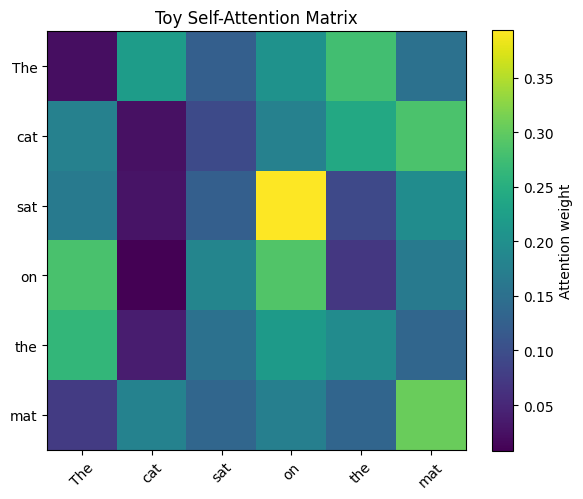

In [2]:
tokens = ['The', 'cat', 'sat', 'on', 'the', 'mat']

# A toy attention matrix (normally learned during training - here we simulate it)
np.random.seed(7)
raw_scores = np.random.rand(len(tokens), len(tokens))
attention = raw_scores / raw_scores.sum(axis=1, keepdims=True)  # rows sum to 1, like real attention

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(attention, cmap='viridis')
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, rotation=45)
ax.set_yticklabels(tokens)
ax.set_title('Toy Self-Attention Matrix')
fig.colorbar(cax, label='Attention weight')
plt.tight_layout()
plt.show()

## 4. Tokens & Embeddings (Concept)

**Tokenization** splits text into smaller pieces (tokens) - often words or sub-words - that
the model can process as numbers. **Embeddings** then turn each token into a vector of
numbers that captures its meaning, so that similar words end up with similar vectors.

Let's tokenize a simple sentence and then build embeddings for a small vocabulary using
**TF-IDF** (a simple, classic way to turn text into vectors) as a beginner-friendly stand-in
for the neural embeddings used inside real LLMs.

In [3]:
def simple_tokenize(text):
    # Lowercase and split on word boundaries - a simplified tokenizer for demonstration
    return re.findall(r"[a-zA-Z']+", text.lower())

sentence = "Large Language Models understand language using tokens and embeddings."
tokens_demo = simple_tokenize(sentence)
print('Tokens:', tokens_demo)
print('Token count:', len(tokens_demo))

Tokens: ['large', 'language', 'models', 'understand', 'language', 'using', 'tokens', 'and', 'embeddings']
Token count: 9


In [4]:
documents = [
    "cats are small furry pets",
    "dogs are loyal furry pets",
    "python is a popular programming language",
    "javascript is used for web programming",
]

vectorizer = TfidfVectorizer()
doc_embeddings = vectorizer.fit_transform(documents)

embedding_df = pd.DataFrame(
    doc_embeddings.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f'doc_{i}' for i in range(len(documents))]
)
embedding_df.round(2)

,are,cats,dogs,for,furry,is,javascript,language,loyal,pets,popular,programming,python,small,used,web
doc_0,0.4,0.51,0.00,0.00,0.4,0.00,0.00,0.00,0.00,0.4,0.00,0.00,0.00,0.51,0.00,0.00
doc_1,0.4,0.00,0.51,0.00,0.4,0.00,0.00,0.00,0.51,0.4,0.00,0.00,0.00,0.00,0.00,0.00
doc_2,0.0,0.00,0.00,0.00,0.0,0.38,0.00,0.49,0.00,0.0,0.49,0.38,0.49,0.00,0.00,0.00
doc_3,0.0,0.00,0.00,0.44,0.0,0.34,0.44,0.00,0.00,0.0,0.00,0.34,0.00,0.00,0.44,0.44


Now let's measure how *similar* two documents are using **cosine similarity** between their embedding vectors - the same idea LLMs use to compare meanings.

In [5]:
similarity_matrix = cosine_similarity(doc_embeddings)

sim_df = pd.DataFrame(
    similarity_matrix,
    columns=[f'doc_{i}' for i in range(len(documents))],
    index=[f'doc_{i}' for i in range(len(documents))]
)
sim_df.round(2)

,doc_0,doc_1,doc_2,doc_3
doc_0,1.00,0.48,0.00,0.00
doc_1,0.48,1.00,0.00,0.00
doc_2,0.00,0.00,1.00,0.26
doc_3,0.00,0.00,0.26,1.00


In [6]:
print('doc_0:', documents[0])
print('doc_1:', documents[1])
print(f"Similarity (cats vs dogs): {similarity_matrix[0][1]:.2f}")
print()
print('doc_0:', documents[0])
print('doc_2:', documents[2])
print(f"Similarity (cats vs python): {similarity_matrix[0][2]:.2f}")

doc_0: cats are small furry pets
doc_1: dogs are loyal furry pets
Similarity (cats vs dogs): 0.48

doc_0: cats are small furry pets
doc_2: python is a popular programming language
Similarity (cats vs python): 0.00


## 5. Prompt Engineering Techniques

**Prompt engineering** is the practice of writing inputs (prompts) that guide an LLM toward a
better, more accurate response. A few common techniques:

- **Zero-shot** - just ask directly, with no examples.
- **Few-shot** - give the model a few examples of the task before asking.
- **Chain-of-thought (CoT)** - ask the model to reason step by step.
- **Role/system prompting** - tell the model what role or persona to take on.

Below we define each style as a template, and use a small **mock LLM** function (simple
pattern-matching) so we can see how the *prompt itself* changes without needing a live API.

In [7]:
def mock_llm(prompt: str) -> str:
    """A very small rule-based stand-in for a real LLM, used only to demonstrate
    how different prompt styles change the shape of a response."""
    prompt_lower = prompt.lower()

    if 'step by step' in prompt_lower or 'reasoning' in prompt_lower:
        return (
            "Step 1: Identify the numbers. Step 2: Apply the operation. "
            "Step 3: Combine results.\nFinal Answer: 42"
        )
    if 'example' in prompt_lower or 'e.g.' in prompt_lower:
        return "Following the pattern from the examples -> Answer: Positive"
    if prompt_lower.startswith('you are'):
        return "[Responding in character] Certainly! Here is my expert answer..."
    return "This is a direct, zero-shot style answer."


zero_shot = "Classify the sentiment of this review: 'The movie was fantastic!'"

few_shot = """Classify the sentiment as Positive or Negative.
Review: 'I loved this product' -> Positive
Review: 'This was a waste of money' -> Negative
Review: 'The movie was fantastic!' -> ?"""

chain_of_thought = (
    "Solve this problem step by step, showing your reasoning: "
    "If a train travels 60 km in 1.5 hours, what is its average speed?"
)

role_prompt = "You are an expert data scientist. Explain what an embedding is to a beginner."

for name, prompt in [
    ('Zero-shot', zero_shot),
    ('Few-shot', few_shot),
    ('Chain-of-thought', chain_of_thought),
    ('Role prompting', role_prompt),
]:
    print(f'--- {name} ---')
    print('Prompt:', prompt[:80] + ('...' if len(prompt) > 80 else ''))
    print('Mock response:', mock_llm(prompt))
    print()

--- Zero-shot ---
Prompt: Classify the sentiment of this review: 'The movie was fantastic!'
Mock response: This is a direct, zero-shot style answer.

--- Few-shot ---
Prompt: Classify the sentiment as Positive or Negative.
Review: 'I loved this product' -...
Mock response: This is a direct, zero-shot style answer.

--- Chain-of-thought ---
Prompt: Solve this problem step by step, showing your reasoning: If a train travels 60 k...
Mock response: Step 1: Identify the numbers. Step 2: Apply the operation. Step 3: Combine results.
Final Answer: 42

--- Role prompting ---
Prompt: You are an expert data scientist. Explain what an embedding is to a beginner.
Mock response: [Responding in character] Certainly! Here is my expert answer...



## 6. RAG Concept (Retrieval-Augmented Generation)

LLMs only know what they were trained on, and can "hallucinate" facts they don't actually
know. **RAG** fixes this by adding a **retrieval step**: before generating an answer, the
system searches a knowledge base for the most relevant documents, and gives those to the
model as extra context.

RAG has two stages:

1. **Retrieve** - find the most relevant document(s) for the user's question.
2. **Generate** - use the retrieved context (plus the question) to produce an answer.

Let's build a tiny knowledge base and a mini RAG pipeline.

In [8]:
knowledge_base = [
    "The Eiffel Tower is located in Paris, France, and was completed in 1889.",
    "Python is a high-level programming language known for its readability.",
    "The mitochondria is the powerhouse of the cell, producing energy as ATP.",
    "RAG stands for Retrieval-Augmented Generation, combining search with text generation.",
    "The Great Wall of China stretches over 21,000 kilometers.",
]

kb_vectorizer = TfidfVectorizer()
kb_embeddings = kb_vectorizer.fit_transform(knowledge_base)

def retrieve(query, top_k=1):
    query_vec = kb_vectorizer.transform([query])
    scores = cosine_similarity(query_vec, kb_embeddings)[0]
    top_indices = scores.argsort()[::-1][:top_k]
    return [(knowledge_base[i], scores[i]) for i in top_indices]

def rag_answer(query):
    retrieved_docs = retrieve(query, top_k=1)
    context, score = retrieved_docs[0]
    # "Generation" step - normally an LLM call; here we template the retrieved context
    return f"Based on retrieved context (similarity={score:.2f}): {context}"

for question in [
    "Where is the Eiffel Tower?",
    "What does RAG mean?",
    "What produces energy in a cell?",
]:
    print('Q:', question)
    print('A:', rag_answer(question))
    print()

Q: Where is the Eiffel Tower?
A: Based on retrieved context (similarity=0.46): The Eiffel Tower is located in Paris, France, and was completed in 1889.

Q: What does RAG mean?
A: Based on retrieved context (similarity=0.28): RAG stands for Retrieval-Augmented Generation, combining search with text generation.

Q: What produces energy in a cell?
A: Based on retrieved context (similarity=0.33): The mitochondria is the powerhouse of the cell, producing energy as ATP.



## 7. Vector Databases Overview

A **vector database** stores embeddings (numeric vectors) and lets you search for the most
*similar* vectors to a query - this is exactly what powers the retrieval step in RAG. Real
vector databases (e.g. Pinecone, Chroma, FAISS, Weaviate) are optimized to do this search
efficiently over millions of vectors.

We already built a tiny version of this above. Let's wrap it in a small `SimpleVectorStore`
class to make the "vector database" concept explicit and reusable.

In [9]:
class SimpleVectorStore:
    """A minimal in-memory vector store: add documents, then search by similarity.
    This mirrors what a real vector database does, just without the scale or persistence."""

    def __init__(self):
        self.documents = []
        self.vectorizer = TfidfVectorizer()
        self.embeddings = None

    def add_documents(self, docs):
        self.documents.extend(docs)
        self.embeddings = self.vectorizer.fit_transform(self.documents)

    def search(self, query, top_k=2):
        query_vec = self.vectorizer.transform([query])
        scores = cosine_similarity(query_vec, self.embeddings)[0]
        top_indices = scores.argsort()[::-1][:top_k]
        return [(self.documents[i], round(float(scores[i]), 2)) for i in top_indices]


store = SimpleVectorStore()
store.add_documents(knowledge_base)

results = store.search("Tell me about famous landmarks", top_k=2)
for doc, score in results:
    print(f'[{score}] {doc}')

[0.0] The Great Wall of China stretches over 21,000 kilometers.
[0.0] RAG stands for Retrieval-Augmented Generation, combining search with text generation.


## 8. LangChain Basics

**LangChain** is a popular framework for building LLM applications. Two of its core building
blocks are:

- **PromptTemplate** - a reusable template with placeholders that get filled in at runtime.
- **Chain** - links steps together (e.g. prompt -> LLM -> output, or retrieval -> prompt -> LLM).

Below we implement lightweight versions of these two ideas in plain Python, to show the
*pattern* LangChain follows (a real project would `from langchain.prompts import PromptTemplate`
and connect it to an actual LLM provider).

In [10]:
class PromptTemplate:
    """A minimal stand-in for LangChain's PromptTemplate."""

    def __init__(self, template: str):
        self.template = template

    def format(self, **kwargs) -> str:
        return self.template.format(**kwargs)


class SimpleChain:
    """A minimal stand-in for a LangChain Chain: prompt -> (mock) LLM -> output."""

    def __init__(self, prompt_template: PromptTemplate, llm_fn):
        self.prompt_template = prompt_template
        self.llm_fn = llm_fn

    def run(self, **kwargs) -> str:
        prompt = self.prompt_template.format(**kwargs)
        return self.llm_fn(prompt)


qa_template = PromptTemplate(
    "You are a helpful assistant. Using this context: '{context}', answer the question: '{question}'"
)

def context_aware_mock_llm(prompt: str) -> str:
    # Extract the context between quotes right after 'context:' for a simple demo answer
    match = re.search(r"context: '(.*?)'", prompt)
    context = match.group(1) if match else "no context found"
    return f"Answer (grounded in context): {context}"


qa_chain = SimpleChain(qa_template, context_aware_mock_llm)

context_text, _ = retrieve("Great Wall length")[0]
response = qa_chain.run(context=context_text, question="How long is the Great Wall of China?")
print(response)

Answer (grounded in context): The Great Wall of China stretches over 21,000 kilometers.


## 9. AI Agents Overview

An **AI agent** combines an LLM with **tools** (like a calculator, a search engine, or a
database) and a decision loop: the agent looks at the user's request, decides *which tool*
to use (if any), calls it, and then responds. This is often called the **ReAct** pattern
(Reason + Act).

Below is a simple rule-based agent that chooses between a **calculator tool** and our
**knowledge-base tool** depending on the request - a beginner-friendly simulation of how
a real LLM-powered agent decides which tool to call.

In [11]:
def calculator_tool(expression: str) -> str:
    try:
        # Only allow safe arithmetic characters
        if re.fullmatch(r"[0-9\.\+\-\*/\(\)\s]+", expression):
            return f"Result: {eval(expression)}"
        return "Calculator error: unsafe expression"
    except Exception as e:
        return f"Calculator error: {e}"

def knowledge_base_tool(query: str) -> str:
    doc, score = retrieve(query, top_k=1)[0]
    return f"Knowledge base result (score={score:.2f}): {doc}"

def simple_agent(user_request: str) -> str:
    # 'Reason' step - decide which tool fits the request
    has_math = bool(re.search(r"[0-9]+\s*[\+\-\*/]\s*[0-9]+", user_request))

    if has_math:
        expression = re.search(r"[0-9\.\+\-\*/\(\)\s]+", user_request).group()
        tool_used = 'Calculator Tool'
        result = calculator_tool(expression)
    else:
        tool_used = 'Knowledge Base Tool'
        result = knowledge_base_tool(user_request)

    return f"[Agent] Chose: {tool_used}\n[Agent] {result}"


for request in [
    "What is 25 * 4 + 10?",
    "Tell me about the Eiffel Tower",
    "How much is 100 / 5?",
]:
    print('User:', request)
    print(simple_agent(request))
    print()

User: What is 25 * 4 + 10?
[Agent] Chose: Calculator Tool
[Agent] Calculator error: invalid syntax (<string>, line 0)

User: Tell me about the Eiffel Tower
[Agent] Chose: Knowledge Base Tool
[Agent] Knowledge base result (score=0.42): The Eiffel Tower is located in Paris, France, and was completed in 1889.

User: How much is 100 / 5?
[Agent] Chose: Calculator Tool
[Agent] Calculator error: invalid syntax (<string>, line 0)



## 10. Responsible AI

Building LLM applications comes with responsibility. Key principles include:

- **Bias & Fairness** - models can reflect biases present in training data; outputs should be
  reviewed for fairness across groups.
- **Transparency & Explainability** - users should know they're interacting with an AI, and
  understand (at a high level) how answers are produced (e.g. citing retrieved sources in RAG).
- **Privacy & Data Protection** - avoid sending sensitive personal data to third-party models
  without consent; be careful about what gets logged or stored.
- **Safety Guardrails** - filter harmful, unsafe, or inappropriate requests and responses.

Below is a very small, illustrative **content moderation** check - real systems use much more
robust, well-tested moderation models, but this shows the *idea* of a safety guardrail sitting
in front of a chatbot.

In [12]:
BLOCKED_KEYWORDS = ['hack into', 'make a bomb', 'self-harm']

def moderate(user_input: str):
    lowered = user_input.lower()
    for keyword in BLOCKED_KEYWORDS:
        if keyword in lowered:
            return False, f"Request blocked by safety guardrail (matched: '{keyword}')"
    return True, "Request passed moderation checks"

for sample in ["How do I bake a cake?", "How do I hack into a system?"]:
    allowed, reason = moderate(sample)
    print(f"Input: {sample!r} -> Allowed: {allowed} | {reason}")

Input: 'How do I bake a cake?' -> Allowed: True | Request passed moderation checks
Input: 'How do I hack into a system?' -> Allowed: False | Request blocked by safety guardrail (matched: 'hack into')


## 11. Proof of Concept - AI Chatbot with Prompt Engineering + RAG

Let's bring everything together into one simple chatbot function that:

1. Runs the input through the **Responsible AI** guardrail.
2. Uses the **agent's reasoning** to pick a tool (calculator vs knowledge base).
3. Uses a **prompt template** to format the final answer, grounded in retrieved context
   when relevant (RAG).

This is intentionally simple (a rule-based "mock LLM") so every part of the pipeline is
visible and easy to reason about - the same overall structure applies when swapping in a
real LLM API.

In [13]:
response_template = PromptTemplate("🤖 Chatbot: {answer}")

def chatbot(user_input: str) -> str:
    allowed, reason = moderate(user_input)
    if not allowed:
        return response_template.format(answer=reason)

    agent_output = simple_agent(user_input)
    # Take just the final result line to keep the chatbot's reply concise
    final_line = agent_output.split('\n')[-1].replace('[Agent] ', '')
    return response_template.format(answer=final_line)


conversation = [
    "What is 12 * 8?",
    "Tell me about Python programming",
    "How do I hack into a system?",
    "What does RAG mean?",
]

for turn in conversation:
    print('User:', turn)
    print(chatbot(turn))
    print()

User: What is 12 * 8?
🤖 Chatbot: Calculator error: invalid syntax (<string>, line 0)

User: Tell me about Python programming
🤖 Chatbot: Knowledge base result (score=0.47): Python is a high-level programming language known for its readability.

User: How do I hack into a system?
🤖 Chatbot: Request blocked by safety guardrail (matched: 'hack into')

User: What does RAG mean?
🤖 Chatbot: Knowledge base result (score=0.28): RAG stands for Retrieval-Augmented Generation, combining search with text generation.



## 12. Summary

- Explored **Transformers** and the intuition behind self-attention.
- Learned **tokens and embeddings**, and measured similarity with cosine similarity.
- Practiced **prompt engineering**: zero-shot, few-shot, chain-of-thought, and role prompting.
- Built a mini **RAG** pipeline: retrieve relevant context, then generate a grounded answer.
- Implemented a simple in-memory **vector store** for similarity search.
- Wrote lightweight, **LangChain-style** `PromptTemplate` and `Chain` classes.
- Built a rule-based **AI agent** that picks between a calculator tool and a knowledge-base tool.
- Applied **Responsible AI** guardrails with a basic content-moderation check.
- Combined everything into a small **AI Chatbot / Prompt-Engineering Proof of Concept**.